In [36]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 

In [37]:
dataset = pd.read_csv("placement.csv")
dataset.head(3)

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25


In [38]:
print("\n\nMissing values\n", dataset.isnull().sum())



Missing values
 cgpa       0
package    0
dtype: int64


In [39]:
print(dataset.columns)

Index(['cgpa', 'package'], dtype='object')


In [40]:
# Remove missing values
dataset_clean = dataset.dropna()
dataset_clean = dataset_clean.reset_index(drop=True)
print(dataset_clean.isnull().sum())
print(len(dataset), len(dataset_clean))  
print(dataset_clean.shape)
print("\n")
print(dataset_clean.head())
print("\n\nMissing values\n", dataset_clean.isnull().sum())

cgpa       0
package    0
dtype: int64
200 200
(200, 2)


   cgpa  package
0  6.89     3.26
1  5.12     1.98
2  7.82     3.25
3  7.42     3.67
4  6.94     3.57


Missing values
 cgpa       0
package    0
dtype: int64


In [41]:
#shuffle dataeset to avoid pattern in data 
# Shuffle and split data
dataset_shuffled = dataset_clean.sample(frac=1).reset_index(drop=True)
train = dataset_shuffled.iloc[:100]
test = dataset_shuffled.iloc[100:202]
print(train.describe())
print(test.describe())

             cgpa     package
count  100.000000  100.000000
mean     6.874800    2.903700
std      1.032157    0.638256
min      4.260000    1.370000
25%      6.127500    2.437500
50%      6.880000    2.885000
75%      7.562500    3.315000
max      9.310000    4.370000
             cgpa     package
count  100.000000  100.000000
mean     7.106200    3.088400
std      1.098376    0.732786
min      4.570000    1.480000
25%      6.287500    2.557500
50%      7.165000    3.100000
75%      7.902500    3.632500
max      9.580000    4.620000


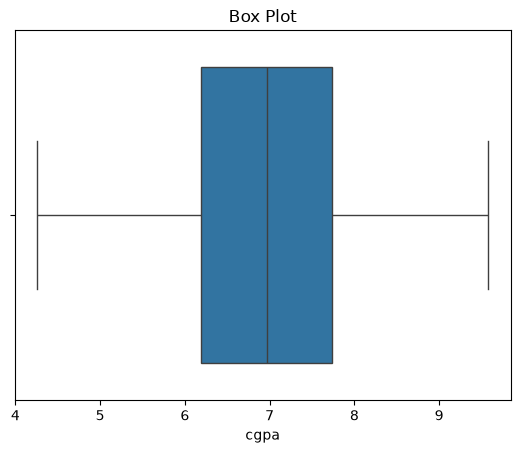

In [42]:
#outlier
sns.boxplot(x="cgpa",data=dataset)
plt.savefig("Outlier_boxplot.png")
plt.title("Box Plot")
plt.show()

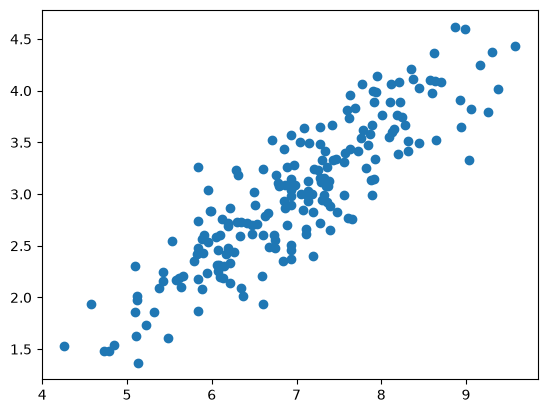

In [43]:
plt.scatter(x="cgpa", y="package",data=dataset)
plt.savefig("Nature_of_data.png")
plt.show()
# Linear plot 

In [44]:
X_train = train[['cgpa']].values.astype(float) # double brackets to keep 2d shape 
y_train = train['package'].values.astype(float)
X_test = test[['cgpa']].values.astype(float)
y_test = test['package'].values.astype(float)
# Extract features and convert to numpy arrays 
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(100, 1) (100,) (100, 1) (100,)


In [45]:
import numpy as np

class SimpleLinearRegression:

    def __init__(self):
        # Initialize parameters
        self.w = 0.0      # Weight (Slope)
        self.b = 0.0      # Bias (Intercept)
        self.losses = []  # Store loss after each iteration

    def fit(self, X, y, learning_rate=0.01, epochs=1000):

        # Convert X into 1-D array
        X = X.flatten()

        # Number of samples
        n = len(X)

        # Gradient Descent
        for epoch in range(epochs):

            # Step 1: Prediction
            y_pred = self.w * X + self.b

            # Step 2: Calculate Error
            error = y_pred - y

            # Step 3: Calculate Loss (MSE)
            loss = np.mean(error ** 2)

            # Store Loss
            self.losses.append(loss)

            # Step 4: Calculate Gradients
            dw = (2 / n) * np.sum(X * error)
            db = (2 / n) * np.sum(error)

            # Step 5: Update Parameters
            self.w = self.w - learning_rate * dw
            self.b = self.b - learning_rate * db

    def predict(self, X):
        X = X.flatten()
        return self.w * X + self.b

    def mse(self, y_true, y_pred):
        return np.mean((y_true - y_pred) ** 2)

    def rmse(self, y_true, y_pred):
        return np.sqrt(self.mse(y_true, y_pred))

    def r2_score(self, y_true, y_pred):
        ss_res = np.sum((y_true - y_pred) ** 2)
        ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
        return 1 - (ss_res / ss_tot)

In [46]:
lr= SimpleLinearRegression()
lr.fit(X_train, y_train, learning_rate=0.01, epochs=1000)


In [47]:
prediction = lr.predict(np.array([[8.85]]))
print(prediction)

[3.81314499]


In [48]:
#MOdel Parameter
print("Weight :", lr.w)
print("Bias :", lr.b)

Weight : 0.4549144775003268
Bias : -0.21284813986086393


In [49]:
y_pred = lr.predict(X_test)

print("MSE :", lr.mse(y_test, y_pred))
print("RMSE :", lr.rmse(y_test, y_pred))
print("R2 Score :", lr.r2_score(y_test, y_pred))

MSE : 0.1296181819562284
RMSE : 0.360025251831352
R2 Score : 0.756175967732331


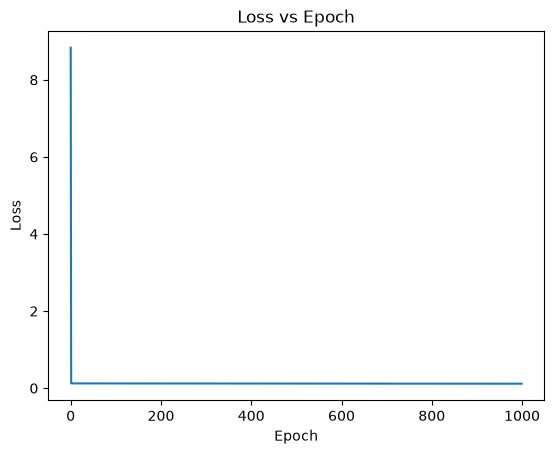

In [50]:
plt.plot(lr.losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epoch")
plt.show()